<a href="https://colab.research.google.com/github/SAMYSOSERIOUS/CS2_Knee_Xray/blob/test/ko_week5_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0️⃣ Install Dependencies & Set Seed

In [ ]:
!pip install timm==0.9.3 opencv-python==4.8.1.76 matplotlib==3.8.0 kaggle==1.5.16 seaborn --quiet

import random, os, numpy as np, torch, gc, pandas as pd
from pathlib import Path
from PI
import cv2, torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import cohen_kappa_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import timm, torch.nn as nn, torch.optim as optim, zipfile

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Device: {device}")

ERROR: Could not find a version that satisfies the requirement timm==0.9.3 (from versions: 0.1.1, 0.1.2, 0.1.4, 0.1.6, 0.1.8, 0.1.10, 0.1.12, 0.1.14, 0.1.16, 0.1.18, 0.1.20, 0.1.22, 0.1.24, 0.1.26, 0.1.28, 0.1.30, 0.2.1, 0.3.0, 0.3.1, 0.3.2, 0.3.3, 0.3.4, 0.4.5, 0.4.9, 0.4.12, 0.5.4, 0.6.2.dev0, 0.6.5, 0.6.7, 0.6.11, 0.6.12, 0.6.13, 0.8.0.dev0, 0.8.2.dev0, 0.8.3.dev0, 0.8.6.dev0, 0.8.10.dev0, 0.8.11.dev0, 0.8.13.dev0, 0.8.15.dev0, 0.8.17.dev0, 0.8.19.dev0, 0.8.21.dev0, 0.8.23.dev0, 0.9.0, 0.9.1, 0.9.2, 0.9.5, 0.9.6, 0.9.7, 0.9.8, 0.9.9, 0.9.10, 0.9.11, 0.9.12, 0.9.16, 1.0.3, 1.0.7, 1.0.8, 1.0.9, 1.0.10, 1.0.11, 1.0.12, 1.0.13, 1.0.14, 1.0.15, 1.0.16, 1.0.17, 1.0.18, 1.0.19, 1.0.20, 1.0.21, 1.0.22, 1.0.23, 1.0.24)
ERROR: No matching distribution found for timm==0.9.3
✅ Device: cuda


# 1️⃣ Mount Google Drive & Paths

In [ ]:
from google.colab import drive, files
DRIVE_BASE = "/content/drive"
drive.mount(DRIVE_BASE, force_remount=True)
BASE_DIR = Path(DRIVE_BASE) / "MyDrive/KOA_QWK_challenge"
folders = ["models","predictions","reports","charts","data"]
for f in folders: (BASE_DIR/f).mkdir(parents=True, exist_ok=True)
PATHS = {f: BASE_DIR/f for f in folders}
print("✅ Paths ready:", PATHS)

Mounted at /content/drive
✅ Paths ready: {'models': PosixPath('/content/drive/MyDrive/KOA_QWK_challenge/models'), 'predictions': PosixPath('/content/drive/MyDrive/KOA_QWK_challenge/predictions'), 'reports': PosixPath('/content/drive/MyDrive/KOA_QWK_challenge/reports'), 'charts': PosixPath('/content/drive/MyDrive/KOA_QWK_challenge/charts'), 'data': PosixPath('/content/drive/MyDrive/KOA_QWK_challenge/data')}


# 2️⃣ Kaggle API Setup

In [ ]:
uploaded = files.upload()  # upload kaggle.json
kaggle_json_path = list(uploaded.keys())[0]
!mkdir -p ~/.kaggle
!cp "{kaggle_json_path}" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle API configured.")

Saving kaggle.json to kaggle.json
✅ Kaggle API configured.


# 3️⃣ Download & Extract Dataset

In [ ]:
def import_kaggle_dataset(dataset_name: str):
    CACHE_DIR = Path("/content/kaggle_cache")
    CACHE_DIR.mkdir(exist_ok=True)
    DATASET_PATH = CACHE_DIR / "dataset"
    if not DATASET_PATH.exists():
        !kaggle datasets download -d {dataset_name} -p {CACHE_DIR} --force
        zip_files = list(CACHE_DIR.glob("*.zip"))
        with zipfile.ZipFile(zip_files[0], "r") as zip_ref:
            zip_ref.extractall(DATASET_PATH)
    print("✅ Dataset ready.")
    return DATASET_PATH

shashwat_root = import_kaggle_dataset("shashwatwork/knee-osteoarthritis-dataset-with-severity")

Dataset URL: https://www.kaggle.com/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity
License(s): Attribution 4.0 International (CC BY 4.0)
 80% 164M/204M [00:00<00:00, 1.71GB/s]
100% 204M/204M [00:00<00:00, 1.72GB/s]
✅ Dataset ready.


# 4️⃣ Clean Dataset

In [ ]:
def clean_folder_dataset(root: Path, source_name: str):
    records, failed = [], []
    for folder, _, files in os.walk(root):
        folder_path = Path(folder)
        try: label = int(folder_path.name)
        except: continue
        for f in files:
            img_path = folder_path / f
            try:
                Image.open(img_path).verify()
                records.append({"image_path": str(img_path), "label": label, "source": source_name})
            except: failed.append(str(img_path))
    if failed: print(f"⚠️ {len(failed)} images failed in {source_name}")
    return pd.DataFrame(records)

shashwat_df = pd.concat([clean_folder_dataset(shashwat_root / s, f"shashwat_{s}")
                         for s in ['train','val','test']], ignore_index=True)

combined_df = shashwat_df
if 'patient_id' not in combined_df.columns:
    combined_df['patient_id'] = combined_df['image_path'].apply(lambda x: Path(x).stem.split("_")[0])
NUM_LABELS = int(combined_df['label'].nunique())
CORAL_DIM = NUM_LABELS-1
print("✅ Combined dataset:", len(combined_df))
print(combined_df['label'].value_counts())

✅ Combined dataset: 8260
label
0    3253
2    2175
1    1495
3    1086
4     251
Name: count, dtype: int64


# 5️⃣ Transforms & Dataset Class

In [ ]:
class CLAHETransform:
    def __call__(self, img):
        g = np.array(img.convert("L"))
        g = cv2.createCLAHE(2.0, (8,8)).apply(g)
        g = np.stack([g]*3, axis=-1)
        return Image.fromarray(g)

class KOADataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        try: img = Image.open(self.df.loc[idx,"image_path"]).convert("RGB")
        except: img = Image.new("RGB", (224,224), (0,0,0))
        label = self.df.loc[idx,"label"]
        if self.transform: img = self.transform(img)
        return img,label

def get_transforms(img_size=224, train=True, tta=False):
    tfms = [CLAHETransform(), T.Resize((img_size,img_size))]
    if train or tta: tfms += [T.RandomHorizontalFlip(), T.RandomRotation(10)]
    tfms += [T.ToTensor(), T.Normalize([0.5]*3,[0.5]*3)]
    return T.Compose(tfms)

# 6️⃣ Cross-Validation Split

In [ ]:
skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
folds = list(skf.split(combined_df, combined_df.label, combined_df.patient_id))
train_idx, val_idx = folds[0]
train_df = combined_df.iloc[train_idx].reset_index(drop=True)
val_df   = combined_df.iloc[val_idx].reset_index(drop=True)
print("Train:", len(train_df), "Val:", len(val_df))

Train: 6608 Val: 1652


# 7️⃣ DataLoaders

In [ ]:
num_workers = 2
def make_loader(df, img_size=224, batch_size=8, train=True, tta=False):
    return DataLoader(KOADataset(df,get_transforms(img_size,train,tta)),
                      batch_size=batch_size, shuffle=train, num_workers=num_workers,
                      pin_memory=True)

# 8️⃣ CORAL Loss

In [ ]:
class CoralLoss(nn.Module):
    def forward(self, logits, labels):
        cum_labels = torch.arange(logits.size(1)).unsqueeze(0).to(logits.device) < labels.unsqueeze(1)
        return nn.BCEWithLogitsLoss()(logits, cum_labels.float())

def coral_decode(logits):
    probs = torch.sigmoid(logits)
    return torch.sum(probs>0.5, dim=1)

# 9️⃣ Training Utilities

In [ ]:
class EarlyStopping:
    def __init__(self, patience=2):
        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0
        self.stop = False
    def step(self,val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            self.stop = self.counter >= self.patience

@torch.no_grad()
def evaluate(model,loader,criterion,coral=False,mixed_precision=False):
    model.eval()
    all_preds, all_labels = [],[]
    val_loss=0
    for imgs,labels in loader:
        imgs,labels = imgs.to(device), labels.to(device)
        with torch.amp.autocast(device_type='cuda', enabled=mixed_precision):
            logits = model(imgs)
            val_loss += criterion(logits, labels).item()
        preds = coral_decode(logits) if coral else logits.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    return cohen_kappa_score(all_labels, all_preds, weights="quadratic"), val_loss/len(loader)

def train_one_epoch(model, loader, optimizer, criterion, mixed_precision=False):
    model.train()
    losses=[]
    scaler = torch.cuda.amp.GradScaler() if mixed_precision else None
    for x,y in tqdm(loader, desc="Train"):
        x,y = x.to(device),y.to(device)
        optimizer.zero_grad()
        if mixed_precision:
            with torch.amp.autocast(device_type='cuda', enabled=True):
                logits = model(x)
                loss = criterion(logits,y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(x)
            loss = criterion(logits,y)
            loss.backward()
            optimizer.step()
        losses.append(loss.item())
    return np.mean(losses)



def train_model_w_logging(name, model, train_loader, val_loader, optimizer, criterion,
                         epochs, coral=False, patience=2, mixed_precision=False, snapshot_ensemble=False,
                         num_snapshots_to_avg=3):
    history = []
    early_stop = EarlyStopping(patience)
    snapshots = []

    for epoch in range(epochs):
        # Train
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, mixed_precision)

        # Validate
        qwk, val_loss = evaluate(model, val_loader, criterion, coral, mixed_precision)
        history.append([epoch, train_loss, val_loss, qwk])
        print(f"{name} | Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, QWK={qwk:.4f}")

        # Save snapshot if needed
        if snapshot_ensemble:
            snapshots.append({k: v.cpu().clone() for k,v in model.state_dict().items()})

        # Early stopping
        early_stop.step(val_loss)
        if early_stop.stop: break

    # 🔧 Handle snapshot ensemble averaging
    if snapshot_ensemble and snapshots:
        num_snapshots = min(num_snapshots_to_avg, len(snapshots))
        soup_state = {k: sum(snapshots[-i][k] for i in range(1,num_snapshots+1))/num_snapshots
                      for k in snapshots[-1]}
        model.load_state_dict(soup_state)
        torch.save(model.state_dict(), PATHS["models"]/ f"{name}_soup.pth")
    else:
        torch.save(model.state_dict(), PATHS["models"]/ f"{name}.pth")

    # Save metrics
    pd.DataFrame(history, columns=["epoch","train_loss","val_loss","qwk"]).to_csv(PATHS["reports"]/f"{name}_metrics.csv", index=False)

    return model, pd.DataFrame(history, columns=["epoch","train_loss","val_loss","qwk"])


# 1️⃣0️⃣ Prepare DataLoaders

In [ ]:
def prepare_loaders(img_size, batch_size):
    return make_loader(train_df,img_size,batch_size,True), make_loader(val_df,img_size,batch_size,False)

# 1️⃣1️⃣ EfficientNet-B5 Training

In [ ]:
# EfficientNet-B5
img_size, batch_size, epochs = 456, 4, 12  # increased epochs
train_loader, val_loader = prepare_loaders(img_size, batch_size)
model_enet = timm.create_model("efficientnet_b5", pretrained=True, num_classes=CORAL_DIM).to(device)
optimizer = optim.AdamW(model_enet.parameters(), lr=3e-4)
criterion = CoralLoss()
model_enet, enet_metrics = train_model_w_logging(
    "efficientnet_b5", model_enet, train_loader, val_loader,
    optimizer, criterion, epochs, coral=True, mixed_precision=True
)
torch.cuda.empty_cache()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/122M [00:00<?, ?B/s]

/tmp/ipython-input-4207157821.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None
Train: 100%|██████████| 1652/1652 [03:07<00:00,  8.83it/s]
/tmp/ipython-input-4207157821.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None


efficientnet_b5 | Epoch 0: train_loss=0.3889, val_loss=0.2663, QWK=0.7677


Train: 100%|██████████| 1652/1652 [02:50<00:00,  9.70it/s]
/tmp/ipython-input-4207157821.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None


...

efficientnet_b5 | Epoch 4: train_loss=0.2482, val_loss=0.2202, QWK=0.8208


Train: 100%|██████████| 1652/1652 [02:58<00:00,  9.25it/s]
/tmp/ipython-input-4207157821.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None


efficientnet_b5 | Epoch 5: train_loss=0.2349, val_loss=0.2329, QWK=0.8094


Train: 100%|██████████| 1652/1652 [02:57<00:00,  9.32it/s]


efficientnet_b5 | Epoch 6: train_loss=0.2254, val_loss=0.2254, QWK=0.8255


# 1️⃣2️⃣ ConvNeXt-Large Snapshot Ensemble

In [ ]:
# ConvNeXt-Large Snapshot Ensemble
img_size, batch_size, epochs = 224, 4, 12  # increased epochs
train_loader, val_loader = prepare_loaders(img_size, batch_size)
model_cnx_l = timm.create_model("convnext_large", pretrained=True, num_classes=CORAL_DIM).to(device)
optimizer = optim.AdamW(model_cnx_l.parameters(), lr=1e-4, weight_decay=1e-4)
model_cnx_l, cnx_l_metrics = train_model_w_logging(
    "convnext_large", model_cnx_l, train_loader, val_loader,
    optimizer, criterion, epochs, coral=True, mixed_precision=True,
    snapshot_ensemble=True
)
torch.cuda.empty_cache()


model.safetensors:   0%|          | 0.00/791M [00:00<?, ?B/s]

/tmp/ipython-input-4207157821.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None
Train: 100%|██████████| 1652/1652 [02:16<00:00, 12.12it/s]


convnext_large | Epoch 0: train_loss=0.2946, val_loss=0.2748, QWK=0.7604


/tmp/ipython-input-4207157821.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None
Train: 100%|██████████| 1652/1652 [02:05<00:00, 13.15it/s]


convnext_large | Epoch 1: train_loss=0.2243, val_loss=0.2038, QWK=0.8368


...

convnext_large | Epoch 3: train_loss=0.1883, val_loss=0.1937, QWK=0.8523


/tmp/ipython-input-4207157821.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None
Train: 100%|██████████| 1652/1652 [02:06<00:00, 13.06it/s]


convnext_large | Epoch 4: train_loss=0.1736, val_loss=0.1948, QWK=0.8453


/tmp/ipython-input-4207157821.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None
Train: 100%|██████████| 1652/1652 [02:06<00:00, 13.06it/s]


convnext_large | Epoch 5: train_loss=0.1612, val_loss=0.2103, QWK=0.8418


# 1️⃣3️⃣ Swin Transformer Training

In [ ]:
# ================================
# Swin Transformer - Fixed Training
# ================================

import timm
import torch.optim as optim

# ---- Hyperparameters ----
img_size, batch_size, epochs = 224, 4, 15  # reduced batch for VRAM
lr = 1e-4  # lower LR for Swin-Large
freeze_stages = 2  # freeze first 2 stages (optional)

# ---- Prepare DataLoaders ----
train_loader, val_loader = prepare_loaders(img_size, batch_size)

# ---- Create Model ----
model_swin = timm.create_model(
    "swin_large_patch4_window7_224",
    pretrained=True,
    num_classes=CORAL_DIM
).to(device)

# ---- Optional: Freeze early layers ----
for name, param in model_swin.named_parameters():
    if any(f"layers.{i}" in name for i in range(freeze_stages)):
        param.requires_grad = False

# ---- Optimizer ----
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model_swin.parameters()), lr=lr)

# ---- Criterion ----
criterion = CoralLoss()

# ---- Updated AMP / GradScaler ----
scaler = torch.amp.GradScaler(enabled=True)

# ---- Train Model ----
model_swin, swin_metrics = train_model_w_logging(
    "swin_large_fixed",
    model_swin,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs,
    coral=True,
    mixed_precision=True,
    snapshot_ensemble=False  # optional
)

# ---- Check QWK per epoch ----
print(swin_metrics)

# ---- Empty cache after training ----
torch.cuda.empty_cache()

# ---- Test first batch logits to ensure non-zero predictions ----
x,y = next(iter(val_loader))
x = x.to(device)
with torch.amp.autocast(device_type='cuda', enabled=True):
    logits = model_swin(x)
print("Logits min/max:", logits.min().item(), logits.max().item())
print("CORAL decode sample:", coral_decode(logits[:8]))


/tmp/ipython-input-4207157821.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None
Train: 100%|██████████| 1652/1652 [03:02<00:00,  9.03it/s]
/tmp/ipython-input-4207157821.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None


swin_large_fixed | Epoch 0: train_loss=0.4760, val_loss=0.6708, QWK=0.4186


Train: 100%|██████████| 1652/1652 [03:02<00:00,  9.04it/s]
/tmp/ipython-input-4207157821.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None


swin_large_fixed | Epoch 1: train_loss=0.3320, val_loss=0.3104, QWK=0.6713


Train: 100%|██████████| 1652/1652 [03:02<00:00,  9.05it/s]
/tmp/ipython-input-4207157821.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None


...

swin_large_fixed | Epoch 4: train_loss=0.2523, val_loss=0.2371, QWK=0.7940


Train: 100%|██████████| 1652/1652 [03:02<00:00,  9.05it/s]
/tmp/ipython-input-4207157821.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if mixed_precision else None


swin_large_fixed | Epoch 5: train_loss=0.2496, val_loss=0.2436, QWK=0.7776


Train: 100%|██████████| 1652/1652 [03:01<00:00,  9.08it/s]


swin_large_fixed | Epoch 6: train_loss=0.2388, val_loss=0.2683, QWK=0.7677
   epoch  train_loss  val_loss       qwk
0      0    0.475997  0.670800  0.418587
1      1    0.332036  0.310432  0.671343
2      2    0.279922  0.252525  0.791761
3      3    0.267371  0.246205  0.786240
4      4    0.252289  0.237058  0.793953
5      5    0.249648  0.243579  0.777602
6      6    0.238761  0.268266  0.767694
Logits min/max: -3.8515625 5.80859375
CORAL decode sample: tensor([2, 4, 4, 3], device='cuda:0')


# 1️⃣4️⃣ Temperature Scaling Utilities

In [ ]:
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1))

    def forward(self, logits):
        return logits / self.temperature

@torch.no_grad()
def collect_logits(model, loader):
    model.eval()
    logits_list, labels_list = [], []
    for x, y in tqdm(loader, desc="Collecting logits"):
        x = x.to(device)
        logits = model(x)
        logits_list.append(logits.cpu())
        labels_list.append(y)
    return torch.cat(logits_list), torch.cat(labels_list)

def apply_temperature_scaling(model, val_loader, criterion):
    print("🔧 Collecting validation logits (GPU → CPU)...")
    logits, labels = collect_logits(model, val_loader)
    logits = logits.float(); labels = labels.long()
    scaler = TemperatureScaler()
    optimizer = torch.optim.LBFGS([scaler.temperature], lr=0.01, max_iter=50)

    def closure():
        optimizer.zero_grad()
        loss = criterion(scaler(logits), labels)
        loss.backward()
        return loss

    optimizer.step(closure)
    print(f"✅ Temperature learned: {scaler.temperature.item():.4f}")

    class ModelWithTemperature(nn.Module):
        def __init__(self, model, temperature):
            super().__init__()
            self.model = model
            self.temperature = temperature
        def forward(self, x):
            return self.model(x) / self.temperature

    return ModelWithTemperature(model, scaler.temperature.to(device))

# Apply temperature scaling to all models
model_enet_temp = apply_temperature_scaling(model_enet, val_loader, criterion)
model_cnx_l_temp = apply_temperature_scaling(model_cnx_l, val_loader, criterion)
model_swin_temp = apply_temperature_scaling(model_swin, val_loader, criterion)


🔧 Collecting validation logits (GPU → CPU)...


✅ Temperature learned: 1.2081
🔧 Collecting validation logits (GPU → CPU)...


✅ Temperature learned: 1.0620
🔧 Collecting validation logits (GPU → CPU)...


✅ Temperature learned: 0.9398


# 1️⃣5️⃣ TTA Inference & Ensemble

In [ ]:


@torch.no_grad()
def tta_predict_labels(model, loader, coral=True, mixed_precision=True):
    model.eval()
    all_preds = []
    for x,_ in loader:
        x = x.to(device)
        with torch.amp.autocast(device_type='cuda', enabled=mixed_precision):
            logits = model(x)
            if coral:
                preds = coral_decode(logits)
            else:
                preds = logits.argmax(1)
        all_preds.extend(preds.cpu().numpy())
    return np.array(all_preds)

tta_loader_enet = make_loader(val_df, img_size=456, batch_size=4, train=False, tta=True)
tta_loader_cnx = make_loader(val_df, img_size=224, batch_size=4, train=False, tta=True)
tta_loader_swin = make_loader(val_df, img_size=224, batch_size=8, train=False, tta=True)

# Use CORAL decoding instead of sum(sigmoid)
scores_enet  = tta_predict_labels(model_enet_temp, tta_loader_enet, coral=True)
scores_cnx_l = tta_predict_labels(model_cnx_l_temp, tta_loader_cnx, coral=True)
scores_swin  = tta_predict_labels(model_swin_temp, tta_loader_swin, coral=True)

# Average of 3 models
ensemble_scores = (scores_enet + scores_cnx_l + scores_swin) / 3.0
ensemble_preds = np.clip(np.round(ensemble_scores), 0, NUM_LABELS-1).astype(int)
val_labels = val_df["label"].values
final_qwk = cohen_kappa_score(val_labels, ensemble_preds, weights="quadratic")
print("✅ Final Ensemble QWK:", final_qwk)


✅ Final Ensemble QWK: 0.8366134615870118


# 1️⃣6️⃣ Save Ensemble Predictions

In [ ]:
ensemble_df = pd.DataFrame({
    "true_label": val_labels,
    "ensemble_score": ensemble_scores,
    "ensemble_pred": ensemble_preds,
    "enet_score": scores_enet,
    "cnx_l_score": scores_cnx_l,
    "swin_score": scores_swin
})
out_path = PATHS["predictions"]/ "ensemble_predictions.csv"
ensemble_df.to_csv(out_path, index=False)
print("✅ Ensemble predictions saved:", out_path)


✅ Ensemble predictions saved: /content/drive/MyDrive/KOA_QWK_challenge/predictions/ensemble_predictions.csv


# 1️⃣7️⃣ Grad-CAM & Attention Maps

In [ ]:
# ==============================
# CELL 17 — Explainability (Grad-CAM, HOOK-FREE)
# CORAL-safe, Swin-safe, no backward hooks
# ==============================

EXPLAIN_DIR = PATHS["charts"] / "explainability"
EXPLAIN_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------
# Helper: find last spatial layer
# -------------------------------------------------
def get_layer_safe(model, layer_name=None):
    modules = dict(model.named_modules())

    if layer_name is not None and layer_name in modules:
        return modules[layer_name]

    for m in reversed(list(model.modules())):
        if isinstance(m, nn.Conv2d):
            return m

    raise ValueError("No suitable spatial layer found for Grad-CAM")


# -------------------------------------------------
# Grad-CAM using autograd.grad (NO HOOKS)
# -------------------------------------------------
def grad_cam(model, x, layer_name=None, coral=False):
    model.eval()

    layer = get_layer_safe(model, layer_name)
    activations = []

    # forward hook ONLY (safe)
    def forward_hook(_, __, output):
        activations.append(output)

    handle = layer.register_forward_hook(forward_hook)

    x = x.unsqueeze(0).to(next(model.parameters()).device)
    logits = model(x)

    # CORAL-safe scalar objective
    loss = logits.sum() if coral else logits.max()

    grads = torch.autograd.grad(
        loss,
        activations[0],
        retain_graph=False,
        create_graph=False
    )[0]

    acts = activations[0][0].detach().cpu().numpy()
    grads = grads[0].detach().cpu().numpy()

    weights = grads.mean(axis=(1, 2))
    cam = np.zeros(acts.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * acts[i]

    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (x.shape[-1], x.shape[-2]))
    cam = (cam - cam.min()) / (cam.max() + 1e-8)

    handle.remove()

    return cam


# -------------------------------------------------
# Save Grad-CAM overlays
# -------------------------------------------------
def save_gradcam_heatmap(
    model,
    loader,
    model_name,
    layer_name=None,
    max_images=10,
    coral=False
):
    model.eval()
    saved = 0

    for imgs, _ in loader:
        for img in imgs:
            if saved >= max_images:
                return

            heatmap = grad_cam(
                model,
                img.to(device),
                layer_name=layer_name,
                coral=coral
            )

            orig = img.cpu().permute(1, 2, 0).numpy()
            orig = ((orig * 0.5 + 0.5) * 255).astype(np.uint8)

            heatmap_rgb = plt.cm.jet(heatmap)[..., :3]
            overlay = np.clip(0.6 * orig / 255 + 0.4 * heatmap_rgb, 0, 1)

            plt.figure(figsize=(4, 4))
            plt.imshow(overlay)
            plt.axis("off")
            plt.title(f"{model_name} Grad-CAM")
            plt.savefig(EXPLAIN_DIR / f"{model_name}_gradcam_{saved}.png", dpi=200)
            plt.close()

            saved += 1


# -------------------------------------------------
# Run Grad-CAM
# -------------------------------------------------
save_gradcam_heatmap(
    model_enet_temp,
    val_loader,
    "efficientnet_b5",
    layer_name="features.conv_head",
    coral=True
)

save_gradcam_heatmap(
    model_cnx_l_temp,
    val_loader,
    "convnext_large",
    layer_name=None,
    coral=True
)

save_gradcam_heatmap(
    model_swin_temp,
    val_loader,
    "swin_large",
    layer_name=None,
    coral=True
)

print("✅ Grad-CAM generated correctly for all models.")


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


✅ Grad-CAM generated correctly for all models.


# 1️⃣8️⃣ Ensemble Report & Dashboard

✅ Final Ensemble Quadratic Weighted Kappa: 0.8366


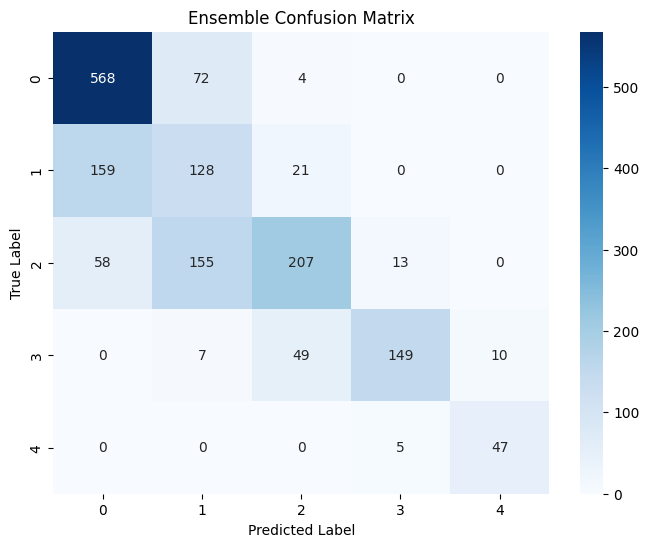

Classification Report:
               precision    recall  f1-score   support

           0     0.7236    0.8820    0.7950       644
           1     0.3536    0.4156    0.3821       308
           2     0.7367    0.4781    0.5798       433
           3     0.8922    0.6930    0.7801       215
           4     0.8246    0.9038    0.8624        52

    accuracy                         0.6653      1652
   macro avg     0.7061    0.6745    0.6799      1652
weighted avg     0.6831    0.6653    0.6618      1652



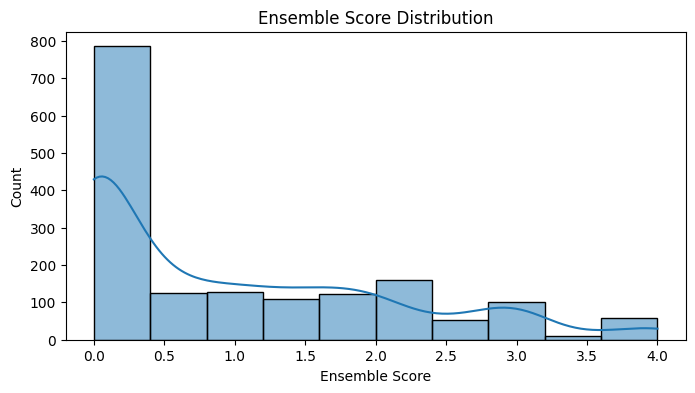

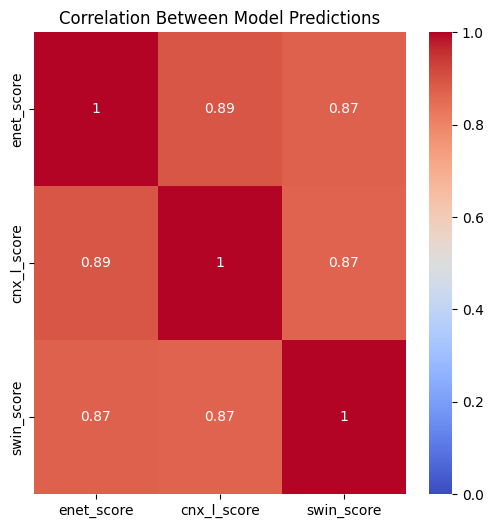

✅ Ensemble report saved: /content/drive/MyDrive/KOA_QWK_challenge/reports/ensemble_full_report.txt


In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ----------------------------
# 1. Overall QWK
# ----------------------------
print(f"✅ Final Ensemble Quadratic Weighted Kappa: {final_qwk:.4f}")

# ----------------------------
# 2. Confusion Matrix
# ----------------------------
cm = confusion_matrix(val_labels, ensemble_preds, labels=list(range(NUM_LABELS)))
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(NUM_LABELS), yticklabels=range(NUM_LABELS))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Ensemble Confusion Matrix")
plt.show()

# ----------------------------
# 3. Classification Report
# ----------------------------
report = classification_report(val_labels, ensemble_preds, digits=4)
print("Classification Report:\n", report)

# ----------------------------
# 4. Ensemble Score Distribution
# ----------------------------
plt.figure(figsize=(8,4))
sns.histplot(ensemble_scores, bins=NUM_LABELS*2, kde=True)
plt.title("Ensemble Score Distribution")
plt.xlabel("Ensemble Score")
plt.ylabel("Count")
plt.show()

# ----------------------------
# 5. Model Contribution Correlation
# ----------------------------
contrib_df = ensemble_df[["enet_score", "cnx_l_score", "swin_score"]]
plt.figure(figsize=(6,6))
sns.heatmap(contrib_df.corr(), annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Correlation Between Model Predictions")
plt.show()

# ----------------------------
# 6. Save full report
# ----------------------------
report_path = PATHS["reports"] / "ensemble_full_report.txt"
with open(report_path, "w") as f:
    f.write(f"Final Ensemble QWK: {final_qwk:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(report)
print("✅ Ensemble report saved:", report_path)

# 1️⃣9️⃣ Interactive Ensemble Weight Dashboard

✅ Weighted Ensemble QWK: 0.8366


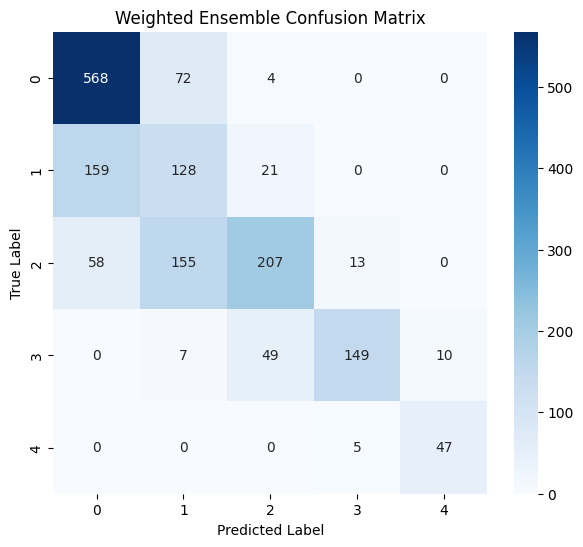

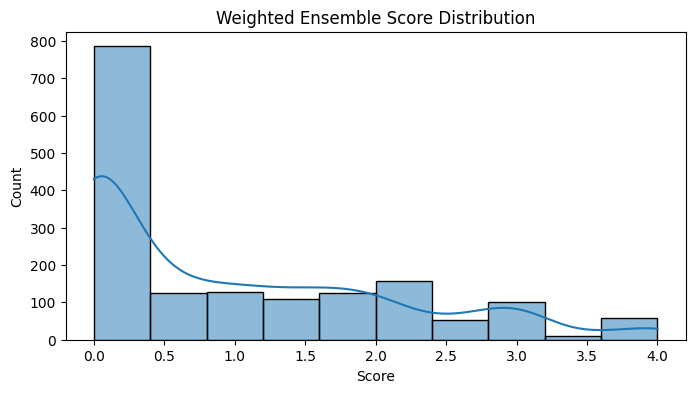

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ----------------------------
# Sliders for model weights
# ----------------------------
w_enet = widgets.FloatSlider(value=0.33, min=0, max=1, step=0.01, description='EffNet-B5:')
w_cnxl = widgets.FloatSlider(value=0.33, min=0, max=1, step=0.01, description='ConvNeXt-L:')
w_swin = widgets.FloatSlider(value=0.34, min=0, max=1, step=0.01, description='Swin-B:')

output = widgets.Output()

def update_dashboard(*args):
    clear_output(wait=True)
    # Normalize weights safely
    weights = np.array([w_enet.value, w_cnxl.value, w_swin.value])
    if weights.sum() == 0:
        weights = np.ones_like(weights) / 3
    else:
        weights = weights / weights.sum()

    # Weighted ensemble
    weighted_scores = (weights[0]*ensemble_df['enet_score'] +
                       weights[1]*ensemble_df['cnx_l_score'] +
                       weights[2]*ensemble_df['swin_score'])

    weighted_preds = np.clip(np.round(weighted_scores), 0, NUM_LABELS-1).astype(int)
    qwk = cohen_kappa_score(val_labels, weighted_preds, weights='quadratic')

    print(f"✅ Weighted Ensemble QWK: {qwk:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(val_labels, weighted_preds, labels=list(range(NUM_LABELS)))
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(NUM_LABELS), yticklabels=range(NUM_LABELS))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Weighted Ensemble Confusion Matrix")
    plt.show()

    # Distribution of weighted scores
    plt.figure(figsize=(8,4))
    sns.histplot(weighted_scores, bins=NUM_LABELS*2, kde=True)
    plt.title("Weighted Ensemble Score Distribution")
    plt.xlabel("Score")
    plt.ylabel("Count")
    plt.show()

# Link sliders to update function
for w in [w_enet, w_cnxl, w_swin]:
    w.observe(update_dashboard, 'value')

display(widgets.VBox([w_enet, w_cnxl, w_swin, output]))
update_dashboard()
